# 07. Simulation, Monte Carlo, and Bootstrap Intuition

Some of the best statistical intuition comes from pretending we could rerun the world many times. What would happen if we kept drawing new audit samples from the same population? How much would the mean move? How much noisier would a 90th percentile be than a simple average? If we only have one sample in hand, how can we approximate that uncertainty from the data we already observed?

We use simulation to make those questions concrete. We will work in a seller-support setting where leadership is considering a premium service commitment. Monte Carlo simulation will let us repeatedly sample from a known population to understand uncertainty. Bootstrap resampling will then show how we can approximate that uncertainty from one observed sample, while also making clear what bootstrap cannot fix: bias in the sampling frame itself.


## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain Monte Carlo simulation as repeated stochastic approximation in a decision workflow.
2. Use repeated sampling to study the sampling distributions of means, rates, and quantiles.
3. Show how larger samples reduce variability for some estimators faster than for others.
4. Explain the law of large numbers intuitively through running averages.
5. Use bootstrap resampling to approximate uncertainty from one observed sample.
6. Compare bootstrap performance for stable statistics such as means versus more fragile statistics such as tail quantiles.
7. Explain why bootstrap can quantify sampling noise but cannot repair a biased frame.


## Mathematical Core: Monte Carlo and Bootstrap Logic

A statistic is a function of the sample:

$$
\hat{\theta} = g(X_1, X_2, \ldots, X_n).
$$

Its sampling distribution is the distribution of $\hat{\theta}$ across hypothetical repeated samples from the same data-generating process. Monte Carlo simulation approximates expectations under that repeated-sampling world by averaging many simulated runs:

$$
\mathbb{E}\left[h(\hat{\theta})\right] \approx \frac{1}{R}\sum_{r=1}^{R} h\left(\hat{\theta}^{(r)}\right).
$$

The Monte Carlo standard error of that simulation average is approximately

$$
SE_{MC} \approx \frac{s_R}{\sqrt{R}},
$$

where $s_R$ is the sample standard deviation of the simulated values. This is why increasing the number of simulation runs stabilizes the simulation output.

The bootstrap uses the empirical distribution of one observed sample:

$$
\hat{F}_n(x) = \frac{1}{n}\sum_{i=1}^n \mathbf{1}(X_i \le x).
$$

A bootstrap replicate draws

$$
X_1^*, \ldots, X_n^* \sim \hat{F}_n
$$

and recomputes the statistic:

$$
\hat{\theta}_b^* = g(X_1^*, \ldots, X_n^*).
$$

Bootstrap variation estimates sampling uncertainty around the observed sample. It cannot repair a biased data source. If the sample is drawn from the wrong frame, the bootstrap repeatedly resamples the wrong frame.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 24)

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display

## 1. Two Simulation Worlds

Simulation enters statistics in two related but distinct ways.


| Simulation World | Core Idea | What It Teaches |
|---|---|---|
| Monte Carlo from a population or model | Repeatedly simulate data from a known stochastic process | What repeated sampling would do if the data-generating mechanism were available |
| Bootstrap from one observed sample | Repeatedly resample rows with replacement from the observed data | How unstable a statistic may be, conditional on the observed sample |


Monte Carlo and bootstrap are cousins, but not twins. Monte Carlo assumes we can generate fresh data from a known process or a known population. Bootstrap assumes we cannot do that, so we treat the observed sample as a stand-in world and resample from it.

That difference matters. Monte Carlo can reveal the true sampling distribution in a teaching simulation. Bootstrap can only approximate it from what the sample has already shown us. When the sample is representative, that can work well. When the sample is biased, bootstrap faithfully resamples the bias too.

## 2. Simulating a Population for Premium Support Decisions

We simulate a large support-ticket population for priority-contract sellers and non-priority sellers. The decision context is a premium service promise, so the quantities of interest are mean first-response minutes, response breach rate relative to a 15-minute target, 90th percentile response time, and average service-credit cost.

### Dataset and Experiment Design

Each row is one ticket with priority-contract status, case severity, queue load, channel, response time, breach status, and service-credit exposure. Because the population is synthetic, we can calculate the true population quantities before drawing any samples. That gives us a benchmark for judging what repeated samples and bootstrap resamples are doing.

The experiment has two parts. First, Monte Carlo sampling repeatedly draws fresh samples from the known population to show the sampling distribution of common statistics. Second, bootstrap resampling starts from one observed audit sample and resamples that audit to estimate uncertainty. A biased dashboard frame is included so the notebook can show an important limitation: resampling can quantify variation around the data you have, but it does not automatically make the data representative.

In [2]:
# Define helper functions and reusable utilities for this section.
rng = np.random.default_rng(2037)

def sigmoid(x):
    """
    Transform a linear score into a probability with the logistic function.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
    
    Returns:
        A scalar or NumPy array containing the logistic transform of `x`, useful for converting linear scores into probabilities.
    
    Idea:
        Convert additive risk drivers into bounded probabilities, allowing synthetic event rates to respond smoothly to covariates.
    """
    return 1.0 / (1.0 + np.exp(-x))


n_tickets = 110_000
seller_tier_levels = np.array(["standard", "growth", "enterprise"])
severity_levels = ["low", "medium", "high", "urgent"]
channel_levels = np.array(["chat", "email", "phone"])

seller_tier = rng.choice(seller_tier_levels, size=n_tickets, p=[0.61, 0.25, 0.14])
priority_contract = (
    (seller_tier == "enterprise")
    | ((seller_tier == "growth") & (rng.random(n_tickets) < 0.36))
).astype(int)

latent_complexity = rng.normal(
    loc=-0.16
    + 0.18 * (seller_tier == "growth")
    + 0.42 * (seller_tier == "enterprise"),
    scale=0.82,
    size=n_tickets,
)

severity_score = latent_complexity + 0.18 * priority_contract + rng.normal(0, 0.90, size=n_tickets)
severity = pd.cut(
    severity_score,
    bins=[-np.inf, -0.55, 0.35, 1.05, np.inf],
    labels=severity_levels,
)
severity = pd.Categorical(severity, categories=severity_levels, ordered=True)

channel_probability_map = {
    "low": [0.64, 0.27, 0.09],
    "medium": [0.46, 0.35, 0.19],
    "high": [0.27, 0.37, 0.36],
    "urgent": [0.09, 0.31, 0.60],
}

channel = np.empty(n_tickets, dtype=object)
for sev, probs in channel_probability_map.items():
    mask = severity == sev
    channel[mask] = rng.choice(channel_levels, size=mask.sum(), p=probs)

overnight_prob = sigmoid(
    -2.10
    + 0.62 * (severity == "urgent").astype(float)
    + 0.24 * (channel == "phone").astype(float)
)
overnight = rng.binomial(1, overnight_prob)

queue_load = rng.normal(
    loc=-0.05
    + 0.22 * (severity == "high").astype(float)
    + 0.50 * (severity == "urgent").astype(float)
    + 0.32 * overnight,
    scale=0.78,
    size=n_tickets,
)
queue_load = np.clip(queue_load, -2.2, 3.2)

response_log = (
    1.92
    + np.select(
        [severity == "low", severity == "medium", severity == "high", severity == "urgent"],
        [-0.25, 0.00, 0.43, 0.82],
    )
    + 0.28 * queue_load
    + 0.20 * overnight
    + 0.11 * (channel == "phone").astype(float)
    + rng.normal(0, 0.34, size=n_tickets)
)
routine_response = np.exp(response_log)

escalation_prob = sigmoid(
    -3.10
    + 0.58 * (severity == "high").astype(float)
    + 1.10 * (severity == "urgent").astype(float)
    + 0.42 * queue_load
    + 0.18 * (channel == "phone").astype(float)
)
escalated_case = rng.binomial(1, escalation_prob)
escalation_delay = escalated_case * rng.lognormal(mean=np.log(22), sigma=0.72, size=n_tickets)

response_minutes = routine_response + escalation_delay
breach = (response_minutes > 15).astype(int)
service_credit = np.where(priority_contract == 1, np.where(breach == 1, 90.0, 0.0), np.where(breach == 1, 25.0, 0.0))

dashboard_logged_prob = sigmoid(
    2.15
    - 1.05 * (channel == "phone").astype(float)
    - 0.92 * overnight
    - 0.68 * (severity == "urgent").astype(float)
    - 0.22 * (severity == "high").astype(float)
    + 0.22 * priority_contract
)
dashboard_logged = rng.binomial(1, dashboard_logged_prob)

population = pd.DataFrame(
    {
        "seller_tier": seller_tier,
        "priority_contract": priority_contract,
        "severity": severity,
        "channel": channel,
        "overnight": overnight,
        "queue_load": queue_load,
        "response_minutes": response_minutes,
        "breach": breach,
        "service_credit": service_credit,
        "dashboard_logged": dashboard_logged,
    }
)

priority_population = population.loc[population["priority_contract"] == 1].copy().reset_index(drop=True)
priority_dashboard_frame = priority_population.loc[priority_population["dashboard_logged"] == 1].copy().reset_index(drop=True)

audit_sample = priority_population.sample(n=600, random_state=2037).reset_index(drop=True)
dashboard_sample = priority_dashboard_frame.sample(n=600, random_state=2038).reset_index(drop=True)

def support_metrics(df):
    """
    Compute the support metrics quantity used in the statistical or decision-science workflow.
    
    Parameters:
        df: Input DataFrame used by the summary, model, or display helper.
    
    Returns:
        A dictionary of support-operation metrics such as response time, breach rate, tail response time, and service-credit exposure.
    
    Idea:
        Collect service metrics that matter together, emphasizing that decision quality depends on averages, tails, and failure rates.
    """
    return {
        "mean_response_minutes": df["response_minutes"].mean(),
        "breach_rate": df["breach"].mean(),
        "p90_response_minutes": df["response_minutes"].quantile(0.90),
        "mean_service_credit": df["service_credit"].mean(),
    }


population_truth = support_metrics(priority_population)
overview = pd.DataFrame(
    [
        {"quantity": "Priority tickets in population", "value": len(priority_population)},
        {"quantity": "Priority tickets visible in dashboard frame", "value": len(priority_dashboard_frame)},
        {"quantity": "Population mean response minutes", "value": population_truth["mean_response_minutes"]},
        {"quantity": "Population breach rate", "value": population_truth["breach_rate"]},
        {"quantity": "Population 90th percentile response", "value": population_truth["p90_response_minutes"]},
        {"quantity": "Population mean service credit", "value": population_truth["mean_service_credit"]},
    ]
)

smart_display(overview)

,quantity,value
0,Priority tickets in population,25345.000
1,Priority tickets visible in dashboard frame,20707.000
2,Population mean response minutes,14.837
3,Population breach rate,0.323
4,Population 90th percentile response,30.023
5,Population mean service credit,29.097


This simulated population gives us a luxury we do not have in live work: the truth is visible. That lets us benchmark how a statistic behaves under repeated sampling.

The premium-support subset is the natural focus because this is the part of the business where bad tail performance can directly trigger credits and reputation damage. We also retain a biased dashboard frame so that later in the lecture we can show a subtle but crucial point: bootstrap uncertainty around a biased sample is still uncertainty around the wrong center.

## 3. Monte Carlo Sampling Distributions

We now repeatedly draw simple random samples from the priority-ticket population. This is Monte Carlo in its most intuitive form: draw, compute, repeat.

We compare three sample sizes and three statistics:

- mean response minutes;
- breach rate;
- 90th percentile response minutes.

The expectation is that larger samples will stabilize all three, but not equally fast. Tail quantiles usually remain noisier than means.


In [3]:
# Define helper functions so repeated calculations stay readable.
def repeated_sample_metrics(frame, sample_sizes, n_draws=1000, seed=88):
    """
    Compute the repeated sample metrics quantity used in the statistical or decision-science workflow.
    
    Parameters:
        frame: Input DataFrame or data slice to summarize.
        sample_sizes: Collection of sample sizes to evaluate in the repeated-sampling study.
        n_draws: Sample size or group size used by the simulation, resampling, or inference step.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A pandas DataFrame of repeated-sample metric estimates used to visualize sampling variability.
    
    Idea:
        Show how operational summaries vary across samples, reinforcing that a dashboard number is one realization of a noisy process.
    """
    local_rng = np.random.default_rng(seed)
    idx = np.arange(len(frame))
    rows = []
    for n in sample_sizes:
        for draw in range(n_draws):
            chosen = local_rng.choice(idx, size=n, replace=False)
            sample = frame.iloc[chosen]
            rows.append(
                {
                    "sample_size": n,
                    "draw": draw,
                    "mean_response_minutes": sample["response_minutes"].mean(),
                    "breach_rate": sample["breach"].mean(),
                    "p90_response_minutes": sample["response_minutes"].quantile(0.90),
                }
            )
    return pd.DataFrame(rows)


sample_sizes = [150, 600, 2400]
mc_draws = repeated_sample_metrics(priority_population, sample_sizes=sample_sizes, n_draws=1000, seed=2040)

mc_summary = (
    mc_draws.groupby("sample_size", observed=True)
    .agg(
        mean_of_mean_estimates=("mean_response_minutes", "mean"),
        sd_of_mean_estimates=("mean_response_minutes", "std"),
        mean_of_breach_estimates=("breach_rate", "mean"),
        sd_of_breach_estimates=("breach_rate", "std"),
        mean_of_p90_estimates=("p90_response_minutes", "mean"),
        sd_of_p90_estimates=("p90_response_minutes", "std"),
    )
    .reset_index()
)
smart_display(mc_summary)

,sample_size,mean_of_mean_estimates,sd_of_mean_estimates,mean_of_breach_estimates,sd_of_breach_estimates,mean_of_p90_estimates,sd_of_p90_estimates
0,150,14.797,1.163,0.323,0.038,29.763,3.545
1,600,14.840,0.612,0.324,0.019,29.939,1.856
2,2400,14.841,0.289,0.323,0.009,30.005,0.919


These repeated samples make the main warning visible. The same data-generating process can produce noticeably different audit summaries. One sample is evidence about the process, not the process itself.


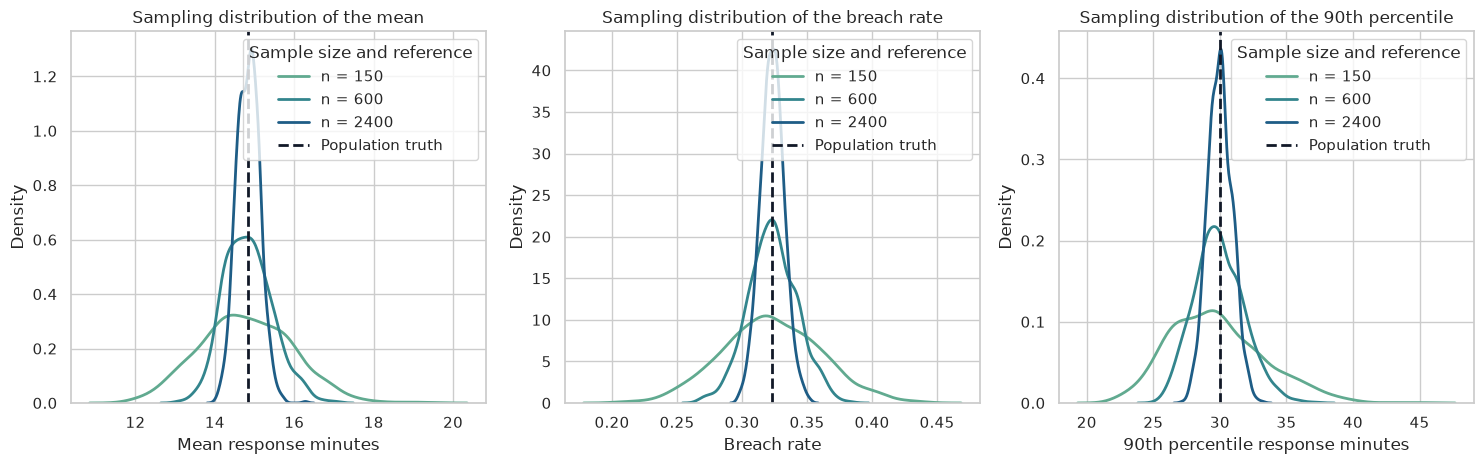

In [4]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

sample_sizes = sorted(mc_draws["sample_size"].unique())
sample_palette = sns.color_palette("crest", n_colors=len(sample_sizes))

for ax, column, title, xlabel, truth in [
    (axes[0], "mean_response_minutes", "Sampling distribution of the mean", "Mean response minutes", population_truth["mean_response_minutes"]),
    (axes[1], "breach_rate", "Sampling distribution of the breach rate", "Breach rate", population_truth["breach_rate"]),
    (axes[2], "p90_response_minutes", "Sampling distribution of the 90th percentile", "90th percentile response minutes", population_truth["p90_response_minutes"]),
]:
    for sample_size, color in zip(sample_sizes, sample_palette):
        sns.kdeplot(
            data=mc_draws.loc[mc_draws["sample_size"] == sample_size],
            x=column,
            common_norm=False,
            linewidth=2,
            color=color,
            label=f"n = {sample_size}",
            ax=ax,
        )
    ax.axvline(truth, color="#111827", linestyle="--", linewidth=2, label="Population truth")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend(title="Sample size and reference")

plt.tight_layout()
plt.show()


These curves show repeated-sampling uncertainty directly. As the sample size grows, the distributions tighten around the population truth. But the tightening is not equally dramatic for every statistic.

The mean response estimate stabilizes relatively quickly because it uses information from every observation. The breach rate also stabilizes, though binary outcomes can still show noticeable noise. The 90th percentile is visibly more fragile because it depends on the upper tail, which is effectively supported by fewer observations.

This is one of the main conceptual payoffs of simulation: it lets us see estimator stability directly.

## 4. Running Averages and the Law of Large Numbers

The law of large numbers says that sample averages tend to stabilize near the population mean as the sample size increases. The theorem is abstract, but the intuition is simple: early randomness matters less and less as more observations accumulate.


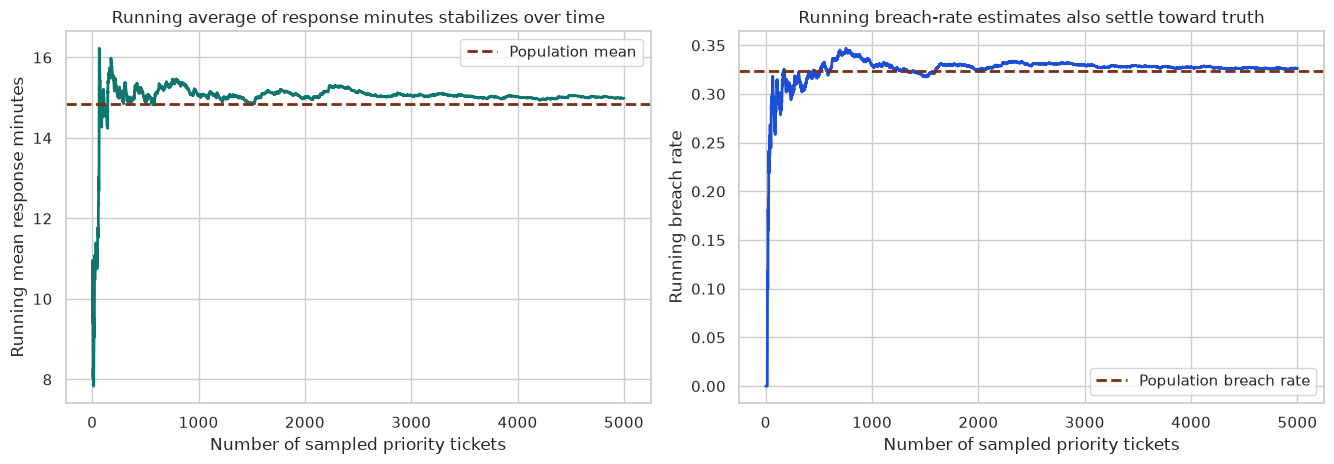

In [5]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
running_tickets = priority_population.sample(n=5000, replace=False, random_state=2041).reset_index(drop=True)
running_tickets["running_mean_response"] = running_tickets["response_minutes"].expanding().mean()
running_tickets["running_breach_rate"] = running_tickets["breach"].expanding().mean()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

axes[0].plot(running_tickets.index + 1, running_tickets["running_mean_response"], color="#0f766e", linewidth=2)
axes[0].axhline(population_truth["mean_response_minutes"], color="#7c2d12", linestyle="--", linewidth=2, label="Population mean")
axes[0].set_title("Running average of response minutes stabilizes over time")
axes[0].set_xlabel("Number of sampled priority tickets")
axes[0].set_ylabel("Running mean response minutes")
axes[0].legend()

axes[1].plot(running_tickets.index + 1, running_tickets["running_breach_rate"], color="#1d4ed8", linewidth=2)
axes[1].axhline(population_truth["breach_rate"], color="#7c2d12", linestyle="--", linewidth=2, label="Population breach rate")
axes[1].set_title("Running breach-rate estimates also settle toward truth")
axes[1].set_xlabel("Number of sampled priority tickets")
axes[1].set_ylabel("Running breach rate")
axes[1].legend()

plt.tight_layout()
plt.show()


These plots show what convergence feels like. Early in the sequence, each additional observation can move the running average substantially. Later on, the path becomes calmer because the accumulated denominator is large and no single ticket dominates.

This is the intuitive core of the law of large numbers. It does not say that every sample path is smooth. It says that long-run averages become more reliable as evidence accumulates.

## 5. Monte Carlo for Decision-Risk Quantities

Simulation is useful for textbook estimator intuition and for complicated risk quantities that have no obvious closed-form answer.

Suppose a premium-support team expects about 260 priority tickets per day. We can simulate many such days and estimate:

- the probability that the daily breach rate exceeds 35%;
- the probability that daily service credits exceed 8,500 dollars.

Monte Carlo turns those probability questions into repeated day-generation exercises.


In [6]:
# Simulate data or resample observations to study variability and uncertainty.
n_days = 1500
tickets_per_day = 260
priority_idx = np.arange(len(priority_population))

daily_rows = []
for day_id in range(n_days):
    chosen = rng.choice(priority_idx, size=tickets_per_day, replace=True)
    day = priority_population.iloc[chosen]
    daily_rows.append(
        {
            "day_id": day_id + 1,
            "daily_breach_rate": day["breach"].mean(),
            "daily_service_credit": day["service_credit"].sum(),
        }
    )

daily_mc = pd.DataFrame(daily_rows)
daily_mc["breach_over_35"] = (daily_mc["daily_breach_rate"] > 0.35).astype(int)
daily_mc["credit_over_8500"] = (daily_mc["daily_service_credit"] > 8500).astype(int)
daily_mc["running_prob_breach_over_35"] = daily_mc["breach_over_35"].expanding().mean()
daily_mc["running_prob_credit_over_8500"] = daily_mc["credit_over_8500"].expanding().mean()

mc_risk_table = pd.DataFrame(
    [
        {"quantity": "P(daily breach rate > 35%)", "value": daily_mc["breach_over_35"].mean()},
        {"quantity": "P(daily service credit > 8500)", "value": daily_mc["credit_over_8500"].mean()},
        {"quantity": "Expected daily service credit", "value": daily_mc["daily_service_credit"].mean()},
        {"quantity": "90th percentile of daily service credit", "value": daily_mc["daily_service_credit"].quantile(0.90)},
    ]
)
smart_display(mc_risk_table)


,quantity,value
0,P(daily breach rate > 35%),0.158
1,P(daily service credit > 8500),0.081
2,Expected daily service credit,7558.860
3,90th percentile of daily service credit,8460.000


The Monte Carlo summary shows the range of answers the procedure can produce when the same decision process is repeated. The mean estimate is useful, but the spread of simulated estimates is what tells us whether the procedure is stable enough to trust for planning.

This is the central reason to simulate. A single run can look decisive by accident. Repeated runs reveal whether the apparent conclusion is a durable feature of the process or just one realization of randomness.


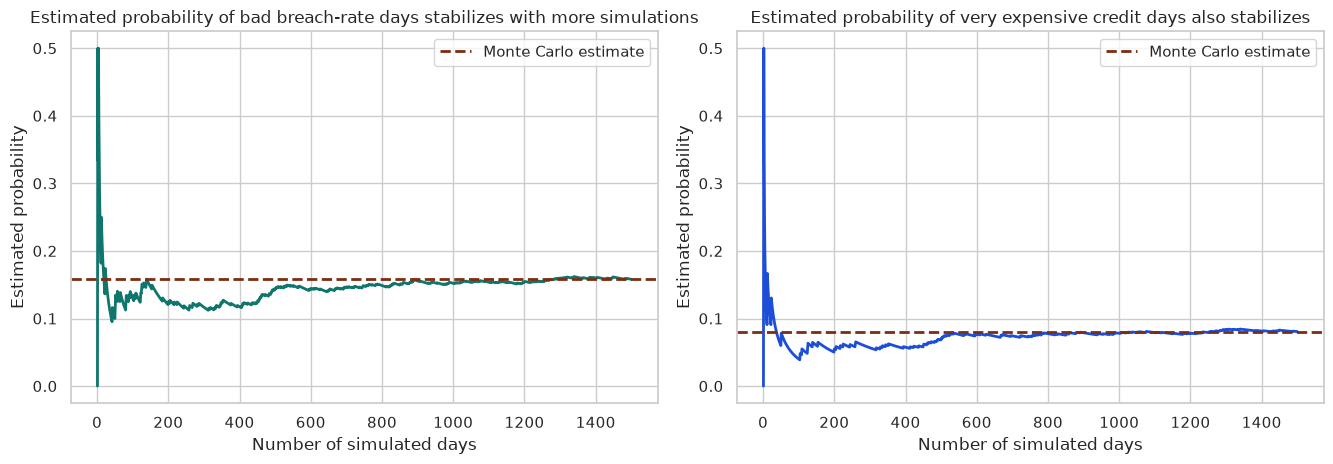

In [7]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

axes[0].plot(daily_mc["day_id"], daily_mc["running_prob_breach_over_35"], color="#0f766e", linewidth=2)
axes[0].axhline(daily_mc["breach_over_35"].mean(), color="#7c2d12", linestyle="--", linewidth=2, label="Monte Carlo estimate")
axes[0].set_title("Estimated probability of bad breach-rate days stabilizes with more simulations")
axes[0].set_xlabel("Number of simulated days")
axes[0].set_ylabel("Estimated probability")
axes[0].legend()

axes[1].plot(daily_mc["day_id"], daily_mc["running_prob_credit_over_8500"], color="#1d4ed8", linewidth=2)
axes[1].axhline(daily_mc["credit_over_8500"].mean(), color="#7c2d12", linestyle="--", linewidth=2, label="Monte Carlo estimate")
axes[1].set_title("Estimated probability of very expensive credit days also stabilizes")
axes[1].set_xlabel("Number of simulated days")
axes[1].set_ylabel("Estimated probability")
axes[1].legend()

plt.tight_layout()
plt.show()


This section shows Monte Carlo in its decision-support role. Repeated simulation estimates the probability of a messy operational event when a closed-form expression is inconvenient.

The running-probability plots also reinforce an important point: Monte Carlo itself has approximation noise. More repetitions usually produce a more stable estimate, but simulation answers are not magically exact unless the simulation budget is very large.

The second threshold is intentionally set near the upper tail of the simulated cost distribution. That makes the event rare enough to be analytically interesting, rare enough to be analytically interesting.

## 6. Bootstrap From One Audit Sample

So far, Monte Carlo has relied on access to the full population. In real work we usually do not have that. Instead, we have one observed sample and want to know how unstable its statistics might be.

The bootstrap answers that by resampling rows with replacement from the observed sample itself. In its simplest form, the idea is straightforward:

1. take the observed sample of size $n$;
2. resample $n$ rows from it with replacement;
3. recompute the statistic;
4. repeat many times.

This creates an empirical approximation to the sampling distribution conditional on the observed sample.


In [8]:
# Define helper functions so repeated calculations stay readable.
def bootstrap_metrics(frame, n_boot=2000, seed=314):
    """
    Generate bootstrap-based metrics results from resampled data.
    
    Parameters:
        frame: Input DataFrame or data slice to summarize.
        n_boot: Sample size or group size used by the simulation, resampling, or inference step.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A pandas DataFrame of bootstrap metric estimates for uncertainty around the observed sample.
    
    Idea:
        Use resampling to attach uncertainty to operational summaries so one sample summary is treated as uncertain evidence.
    """
    local_rng = np.random.default_rng(seed)
    idx = np.arange(len(frame))
    rows = []
    for draw in range(n_boot):
        chosen = local_rng.choice(idx, size=len(frame), replace=True)
        sample = frame.iloc[chosen]
        rows.append(
            {
                "draw": draw,
                "mean_response_minutes": sample["response_minutes"].mean(),
                "breach_rate": sample["breach"].mean(),
                "p90_response_minutes": sample["response_minutes"].quantile(0.90),
            }
        )
    return pd.DataFrame(rows)


audit_boot = bootstrap_metrics(audit_sample, n_boot=2000, seed=2042)

bootstrap_interval_rows = []
for metric in ["mean_response_minutes", "breach_rate", "p90_response_minutes"]:
    low, high = audit_boot[metric].quantile([0.025, 0.975])
    bootstrap_interval_rows.append(
        {
            "metric": metric,
            "population_truth": population_truth[metric],
            "audit_sample_estimate": support_metrics(audit_sample)[metric],
            "bootstrap_ci_low": low,
            "bootstrap_ci_high": high,
        }
    )

bootstrap_interval_table = pd.DataFrame(bootstrap_interval_rows)
smart_display(bootstrap_interval_table)

,metric,population_truth,audit_sample_estimate,bootstrap_ci_low,bootstrap_ci_high
0,mean_response_minutes,14.837,14.032,13.040,15.071
1,breach_rate,0.323,0.305,0.267,0.343
2,p90_response_minutes,30.023,28.662,26.137,31.263


The bootstrap interval is a way to ask how much the estimate might move if the observed data were only one plausible sample from the same process. The resampled distribution gives a practical uncertainty statement without pretending the original sample is the full truth.

For decision science, the interval should shape the recommendation. If the bootstrap range crosses an operational threshold, the correct message is conditional or cautious even when the point estimate looks attractive.


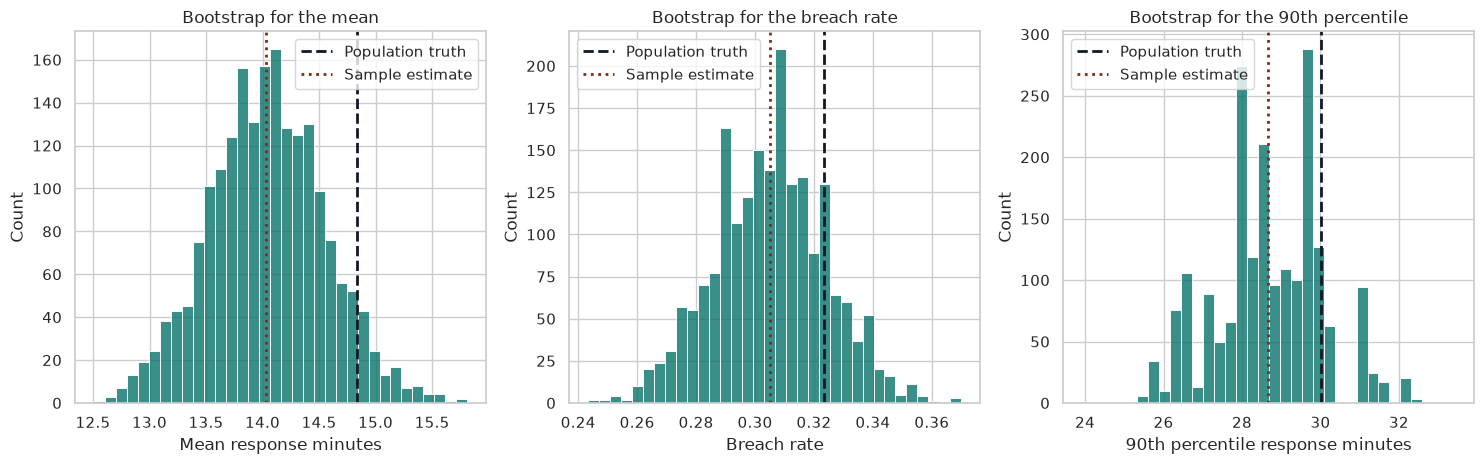

In [9]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

for ax, metric, title, xlabel, truth in [
    (axes[0], "mean_response_minutes", "Bootstrap for the mean", "Mean response minutes", population_truth["mean_response_minutes"]),
    (axes[1], "breach_rate", "Bootstrap for the breach rate", "Breach rate", population_truth["breach_rate"]),
    (axes[2], "p90_response_minutes", "Bootstrap for the 90th percentile", "90th percentile response minutes", population_truth["p90_response_minutes"]),
]:
    sns.histplot(audit_boot[metric], bins=34, color="#0f766e", alpha=0.82, ax=ax)
    ax.axvline(truth, color="#111827", linestyle="--", linewidth=2, label="Population truth")
    ax.axvline(support_metrics(audit_sample)[metric], color="#7c2d12", linestyle=":", linewidth=2, label="Sample estimate")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend()

plt.tight_layout()
plt.show()


For a representative audit sample, the bootstrap usually gives a plausible picture of uncertainty around the sample statistic. The mean and breach-rate intervals tend to be fairly stable. The 90th percentile is often noisier because bootstrap resamples can only learn about the tail from whatever tail observations the sample happened to include.

That is an important practical lesson: bootstrap is often most reliable for smoother statistics and more fragile for extreme quantiles, maxima, and highly irregular functionals.

## 7. Bootstrap Cannot Repair a Biased Frame

The previous notebook argued that a biased frame can create a biased answer. We can now sharpen that statement: bootstrap can quantify uncertainty around a biased sample, but it cannot re-center the estimate on the true population value if the frame itself is distorted.

We demonstrate this by bootstrapping both:

- the representative audit sample;
- the biased dashboard sample.

If the dashboard frame systematically underrepresents hard tickets, then bootstrap from that sample will confidently resample the underrepresentation.


In [10]:
# Simulate data or resample observations to study variability and uncertainty.
dashboard_boot = bootstrap_metrics(dashboard_sample, n_boot=2000, seed=2043)
dashboard_metrics = support_metrics(dashboard_sample)
audit_metrics = support_metrics(audit_sample)

comparison_rows = []
for metric in ["mean_response_minutes", "breach_rate", "p90_response_minutes"]:
    audit_low, audit_high = audit_boot[metric].quantile([0.025, 0.975])
    dash_low, dash_high = dashboard_boot[metric].quantile([0.025, 0.975])
    comparison_rows.append(
        {
            "metric": metric,
            "population_truth": population_truth[metric],
            "audit_estimate": audit_metrics[metric],
            "audit_ci_low": audit_low,
            "audit_ci_high": audit_high,
            "dashboard_estimate": dashboard_metrics[metric],
            "dashboard_ci_low": dash_low,
            "dashboard_ci_high": dash_high,
        }
    )

bootstrap_comparison = pd.DataFrame(comparison_rows)
smart_display(bootstrap_comparison)


,metric,population_truth,audit_estimate,audit_ci_low,audit_ci_high,dashboard_estimate,dashboard_ci_low,dashboard_ci_high
0,mean_response_minutes,14.837,14.032,13.040,15.071,13.379,12.434,14.451
1,breach_rate,0.323,0.305,0.267,0.343,0.288,0.252,0.325
2,p90_response_minutes,30.023,28.662,26.137,31.263,26.746,23.709,29.469


This comparison is one of the deepest bootstrap lessons in the course. The audit-sample intervals are uncertainty statements around a representative sample. The dashboard-sample intervals are uncertainty statements around a distorted sample. The intervals may both be narrow, but that does not make them equally trustworthy.

Bootstrap is not a bias eraser. It is a resampling-based uncertainty tool, and its output inherits the informational limits of the sample it is fed.

## Wrap-Up

We used simulation to make uncertainty tangible:

1. Monte Carlo simulation approximates repeated sampling by generating many synthetic repetitions.
2. Sampling distributions let us see how estimates fluctuate around population truth.
3. Larger samples reduce variability, but tail statistics often remain relatively fragile.
4. Running averages make the law of large numbers intuitive.
5. Monte Carlo is useful for estimating complicated decision-risk quantities when formulas are awkward.
6. Bootstrap approximates uncertainty from one observed sample by resampling with replacement.
7. Bootstrap can describe sampling noise, but it cannot repair a biased sampling frame.

The next notebook will move from simulation intuition to the formal language of estimators: bias, variance, consistency, and efficiency.


## References

- Cochran, J. J. (2019). *What is the bootstrap?* *Significance*, 16(1), 8-9. [https://doi.org/10.1111/j.1740-9713.2019.01225.x](https://doi.org/10.1111/j.1740-9713.2019.01225.x)
- Efron, B. (1979). *Bootstrap methods: Another look at the jackknife*. *The Annals of Statistics*, 7(1), 1-26. [https://doi.org/10.1214/aos/1176344552](https://doi.org/10.1214/aos/1176344552)
- Spiegelhalter, D., Pearson, M., & Short, I. (2011). *Visualizing uncertainty about the future*. *Science*, 333(6048), 1393-1400. [https://doi.org/10.1126/science.1191181](https://doi.org/10.1126/science.1191181)
- Tukey, J. W. (1962). *The future of data analysis*. *The Annals of Mathematical Statistics*, 33(1), 1-67. [https://doi.org/10.1214/aoms/1177704711](https://doi.org/10.1214/aoms/1177704711)
- Tversky, A., & Kahneman, D. (1971). *Belief in the law of small numbers*. *Psychological Bulletin*, 76(2), 105-110. [https://doi.org/10.1037/h0031322](https://doi.org/10.1037/h0031322)
